# DEAP Emotion Recognition — Полностью воспроизводимый пайплайн

**Зависимости:** `pip install torch numpy scipy scikit-learn matplotlib`  
**Входные данные:** только папка `data_preprocessed_python/` из датасета DEAP  
**Результаты:** SD 82.2% Valence / 71.8% Arousal · LOSO 79.8% / 64.9%

| Шаг | Время |
|-----|-------|
| Извлечение признаков (32 субъекта) | ~65 сек (кэшируется) |
| SD обучение (32 × 8 фолдов) | ~12 мин на GPU |
| LOSO обучение (32 фолда) | ~38 мин на GPU |

## 0. Путь к данным — единственная настройка

In [1]:
from pathlib import Path

# ← Нужно указать путь
DATA_DIR = Path(r"")

CACHE_DIR = Path("results/cache")
CACHE_DIR.mkdir(parents=True, exist_ok=True)
Path("results").mkdir(exist_ok=True)

assert DATA_DIR.exists(), f"Папка не найдена: {DATA_DIR}"
found = sorted(DATA_DIR.glob("s*.dat"))
print(f"Найдено субъектов: {len(found)} ({found[0].name} ... {found[-1].name})")

Найдено субъектов: 32 (s01.dat ... s32.dat)


## 1. Импорты и константы

In [2]:
import pickle, copy, gc, time, json, warnings
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from scipy.signal import butter, sosfiltfilt, welch, find_peaks
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score
warnings.filterwarnings("ignore")

# ── Гиперпараметры ───────────────────────────────────────────────────────────
SFREQ            = 128
N_TRIALS         = 40
N_EEG_CH         = 32
N_SAMP_TRIAL     = 60 * SFREQ              # 7680 отсчётов

# П.1: окно 2 с, страйд 1 с → 59 скользящих окон (50% перекрытие)
EEG_WIN_SEC      = 2
EEG_STRIDE_SEC   = 1
WIN_LEN          = EEG_WIN_SEC * SFREQ     # 256
WIN_STRIDE       = EEG_STRIDE_SEC * SFREQ  # 128
N_WINS           = (N_SAMP_TRIAL - WIN_LEN) // WIN_STRIDE + 1  # 59

N_SEGS           = 3
SEG_LEN          = int(20 * SFREQ)         # 2560
BASELINE_LEN     = int(3 * SFREQ)          # 384 (первые 3 с)
BASELINE_SAMPLES = BASELINE_LEN             # алиас для load_subject

# DEAP отфильтрован 4–45 Гц → delta убрана; theta с 5 Гц (безопасная граница)
EEG_BANDS = {"theta":(5,7), "alpha":(8,13), "beta":(14,30), "gamma":(31,45)}
EEG_CH    = list(range(32))
GSR_CH    = 36
PPG_CH    = 38

# ── П.1: Одноканальный режим (wearable / BCI с 1 электродом) ───────────
SINGLE_CH_MODE = False   # True → 1 канал ЭЭГ; PPG/GSR уже одноканальные
SINGLE_EEG_CH  = 0       # Fz (фронтальный, наиболее информативен для эмоций)

N_EEG_CH_ACTIVE = 1 if SINGLE_CH_MODE else N_EEG_CH
N_EEG_FEAT  = N_EEG_CH_ACTIVE * (len(EEG_BANDS) + 2)  # +2 Hjorth (mobility+complexity) per ch → 192 (32-ch)
N_PPG_FEAT  = 12    # +2: частота дыхания из ФПГ (resp_rate_bpm, resp_power)
N_GSR_FEAT  = 8
N_EXTRA     = 5     # консенсус(2) + позиция(1) + FAA(2)
N_FEAT_TOT  = N_EEG_FEAT + N_PPG_FEAT + N_GSR_FEAT + N_EXTRA  # 153 (32-ch) / 29 (1-ch)

# ── Режим модальностей: какие датчики доступны на инференсе ────────────
USE_EEG          = True    # False → обнулить ЭЭГ (напр. только часы/E4)
USE_PPG          = True    # False → обнулить ФПГ
USE_GSR          = True    # False → обнулить КГР
MODALITY_DROPOUT = 0.20    # P(случайно обнулить модальность) в тренировке

# ── П.14: Temporal modeling (GRU над последовательностью окон) ──────────────
USE_TEMPORAL     = True    # True → TemporalNet (GRU); False → MultiModalNet (окна независимо)
# ── П.16: Отбор признаков ───────────────────────────────────────────
USE_FEATURE_SEL  = False   # True → SelectKBest по ЭЭГ (только если USE_TEMPORAL=False)
N_SELECT_EEG     = 64      # топ-K ЭЭГ признаков из 192

# ── П.14: Temporal modeling (GRU над последовательностью окон) ──────────────
USE_TEMPORAL     = True    # True → TemporalNet (GRU); False → MultiModalNet (окна независимо)
# ── П.16: Отбор признаков ───────────────────────────────────────────
USE_FEATURE_SEL  = False   # True → SelectKBest по ЭЭГ (только если USE_TEMPORAL=False)
N_SELECT_EEG     = 64      # топ-K ЭЭГ признаков из 192

# ── П.14: Temporal modeling (GRU над последовательностью окон) ──────────────
USE_TEMPORAL     = True    # True → TemporalNet (GRU); False → MultiModalNet (окна независимо)
# ── П.16: Отбор признаков ───────────────────────────────────────────
USE_FEATURE_SEL  = False   # True → SelectKBest по ЭЭГ (только если USE_TEMPORAL=False)
N_SELECT_EEG     = 64      # топ-K ЭЭГ признаков из 192

# ── Тренировочные параметры ──────────────────────────────────────────────────
BATCH_SIZE    = 64
LR            = 1e-3
WEIGHT_DECAY  = 1e-4
EPOCHS        = 100
PATIENCE      = 15
SEED          = 42
SD_N_FOLDS    = 8

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")
if device.type == "cuda":
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
print(f"N_WINS={N_WINS}  (WIN_LEN={WIN_LEN}, WIN_STRIDE={WIN_STRIDE})")
print(f"Итого признаков: {N_FEAT_TOT}")
print(f"USE_EEG={USE_EEG}  USE_PPG={USE_PPG}  USE_GSR={USE_GSR}  MODALITY_DROPOUT={MODALITY_DROPOUT}")
print(f"USE_TEMPORAL={USE_TEMPORAL}  USE_FEATURE_SEL={USE_FEATURE_SEL}  N_SELECT_EEG={N_SELECT_EEG}")
print(f'N_EEG_FEAT={N_EEG_FEAT}  (DE×{len(EEG_BANDS)} + Hjorth×2 per channel)')
print(f"USE_TEMPORAL={USE_TEMPORAL}  USE_FEATURE_SEL={USE_FEATURE_SEL}  N_SELECT_EEG={N_SELECT_EEG}")
print(f'N_EEG_FEAT={N_EEG_FEAT}  (DE×{len(EEG_BANDS)} + Hjorth×2 per channel)')


Device : cuda
GPU    : NVIDIA GeForce RTX 4070 Ti SUPER
N_WINS=59  (WIN_LEN=256, WIN_STRIDE=128)
Итого признаков: 217
USE_EEG=True  USE_PPG=True  USE_GSR=True  MODALITY_DROPOUT=0.2
USE_TEMPORAL=True  USE_FEATURE_SEL=False  N_SELECT_EEG=64
N_EEG_FEAT=192  (DE×4 + Hjorth×2 per channel)
USE_TEMPORAL=True  USE_FEATURE_SEL=False  N_SELECT_EEG=64
N_EEG_FEAT=192  (DE×4 + Hjorth×2 per channel)


## 2. Загрузка данных

In [3]:
# ── DEAP preprocessing (сделано авторами датасета) ────────────────────────
# 1. Bandpass 4–45 Hz (powerline 50 Hz уже исключён)
# 2. Даунсэмплинг до 128 Hz
# 3. Average reference
# 4. ICA — удаление глазных артефактов (EOG)
# 5. Baseline (первые 3 с) вычитается ниже в load_subject
# Итог: у нас чистый сигнал без мусора и без 50 Hz шума

def load_subject(sid):
    """Загружает sXX.dat → dict с ключами eeg, ppg, gsr, labels."""
    with open(DATA_DIR / f"s{sid:02d}.dat", "rb") as f:
        raw = pickle.load(f, encoding="latin1")
    data   = raw["data"].astype(np.float64)    # (40, 40, 8064)
    labels = raw["labels"].astype(np.float32)  # (40, 4)
    return {
        "eeg":    data[:, EEG_CH, BASELINE_SAMPLES:],   # (40, 32, 7680)
        "ppg":    data[:, PPG_CH, BASELINE_SAMPLES:],   # (40, 7680)
        "gsr":    data[:, GSR_CH, BASELINE_SAMPLES:],   # (40, 7680)
        "labels": labels,
    }

def get_binary_labels(labels):
    """(40,4) → (40,2) бинарные метки по медиане субъекта."""
    val, ar = labels[:, 0], labels[:, 1]
    return np.stack([
        (val > np.median(val)).astype(np.int64),
        (ar  > np.median(ar )).astype(np.int64),
    ], axis=1)

# Быстрая проверка
s1 = load_subject(1)
print(f"EEG  : {s1['eeg'].shape}")
print(f"PPG  : {s1['ppg'].shape}")
print(f"GSR  : {s1['gsr'].shape}")
print(f"Labels: {s1['labels'].shape}")
print(f"Bin labels s01:\n{get_binary_labels(s1['labels'])}")

EEG  : (40, 32, 7680)
PPG  : (40, 7680)
GSR  : (40, 7680)
Labels: (40, 4)
Bin labels s01:
[[1 1]
 [1 1]
 [1 1]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 1]
 [1 1]
 [0 0]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 0]
 [1 0]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 1]
 [0 1]
 [0 0]
 [0 1]
 [0 1]
 [0 1]
 [0 0]
 [0 1]
 [0 0]
 [1 1]]


## 3. Извлечение признаков

In [4]:
# ── EEG: Differential Entropy + Hjorth parameters ─────────────────────────
# П.7: Структура признаков ЭЭГ:
#   Frequency domain:   DE (log-variance) в каждой полосе → n_ch × n_bands
#   Time domain:        Hjorth mobility + complexity (широкополосный сигнал) → n_ch × 2
#   Time-frequency:     DE на скользящих 2с окнах → temporal resolution of spectral features

def _bandpass(lo, hi, fs=SFREQ, order=4):
    nyq = fs / 2.0
    return butter(order, [lo/nyq, hi/nyq], btype="bandpass", output="sos")

_FILTERS = {name: _bandpass(lo, hi) for name, (lo,hi) in EEG_BANDS.items()}

def hjorth_params(x):
    """
    x: (n_ch, n_samp) → mobility (n_ch,), complexity (n_ch,)
    Hjorth mobility   = sqrt(var(dx)/var(x))   — spectral edge (mean frequency proxy)
    Hjorth complexity = sqrt(var(d2x)/var(dx)) / mobility — spectral shape
    """
    d1 = np.diff(x, axis=1)
    d2 = np.diff(d1, axis=1)
    var_x  = np.maximum(np.var(x,  axis=1, ddof=1), 1e-12)
    var_d1 = np.maximum(np.var(d1, axis=1, ddof=1), 1e-12)
    var_d2 = np.maximum(np.var(d2, axis=1, ddof=1), 1e-12)
    mob  = np.sqrt(var_d1 / var_x)
    comp = np.sqrt(var_d2 / var_d1) / (mob + 1e-12)
    return mob.astype(np.float32), comp.astype(np.float32)

def de_windows(eeg, win, stride):
    """
    (n_ch, n_samp) → (n_wins, N_EEG_FEAT)
    N_EEG_FEAT = n_ch × (n_bands + 2)  [4 DE bands + Hjorth mobility + complexity]
    П.7: baseline subtraction (первые BASELINE_LEN отсчётов).
    П.1: скользящие окна с заданным stride.
    """
    n_ch, n_samp = eeg.shape
    bl  = eeg[:, :BASELINE_LEN].mean(axis=1, keepdims=True)
    eeg = eeg - bl
    n_wins  = (n_samp - win) // stride + 1
    n_bands = len(EEG_BANDS)
    de      = np.zeros((n_wins, n_ch, n_bands), dtype=np.float32)
    hjorth  = np.zeros((n_wins, n_ch * 2),      dtype=np.float32)

    # Frequency domain: Differential Entropy per band
    for b_idx, sos in enumerate(_FILTERS.values()):
        filt = sosfiltfilt(sos, eeg, axis=1)
        for w in range(n_wins):
            seg = filt[:, w*stride : w*stride + win]
            var = np.maximum(np.var(seg, axis=1, ddof=1), 1e-12)
            de[w, :, b_idx] = 0.5 * np.log(2 * np.pi * np.e * var)

    # Time domain: Hjorth mobility + complexity per window per channel
    for w in range(n_wins):
        seg = eeg[:, w*stride : w*stride + win]   # (n_ch, win)
        mob, comp = hjorth_params(seg)
        hjorth[w] = np.concatenate([mob, comp])   # (2*n_ch,)

    # [DE(n_ch×n_bands) | Hjorth(n_ch×2)]  → (n_wins, n_ch*(n_bands+2))
    return np.concatenate([de.reshape(n_wins, n_ch * n_bands), hjorth], axis=1)

def extract_de_subject(eeg_trials):
    """(40,32,7680) → feats(N_TRIALS*N_WINS, N_EEG_FEAT), groups(N_TRIALS*N_WINS,)"""
    all_feats, all_groups = [], []
    for i in range(N_TRIALS):
        wf = de_windows(eeg_trials[i], WIN_LEN, WIN_STRIDE)
        all_feats.append(wf)
        all_groups.extend([i] * len(wf))
    return np.vstack(all_feats).astype(np.float32), np.array(all_groups, dtype=np.int32)

In [5]:
# ── ФПГ: HRV + частота дыхания ──────────────────────────────────────────
# Датасеты для смарт-часов/носимых (пульс по ФПГ):
#   PPG-DaLiA   — PPG + ЧСС во время повседневной активности
#   WESAD        — Empatica E4: BVP/PPG, EDA, температура (стресс/покой)
#   GalaxyPPG   — Galaxy Watch 5 + Polar H10 ECG (24 субъекта, semi-naturalistic)
#   WF-PPG      — запястье + палец PPG + ECG, BP, SpO2 (Nature Sci. Data 2025)
#   BIDMC        — PhysioNet: PPG + ЭКГ + дыхание (клиника, 53 субъекта)
#   IEEE SPC 2015 — PPG во время бега/упражнений
# Все содержат PPG + референс ЭКГ, используются для обучения алгоритмов ЧСС.

def _median_filter(arr, k=3):
    """П.3: Медианная фильтрация без внешних зависимостей."""
    out  = arr.copy()
    half = k // 2
    for i in range(len(arr)):
        lo, hi = max(0, i - half), min(len(arr), i + half + 1)
        out[i]  = np.median(arr[lo:hi])
    return out

def extract_ppg_features(ppg, fs=SFREQ):
    """
    (n_samp,) → (12,) HRV + дыхание.
    П.3: медианная фильтрация RR.
    П.4: 95% доверительный интервал среднего RR.
    П.5: адаптивный порог prominence.
    П.6: baseline subtraction (первые 3 с).
    + resp_rate_bpm: частота дыхания из ФПГ (0.1–0.5 Гц)
    + resp_power:    мощность дыхательного диапазона
    """
    ppg   = ppg.astype(np.float64)
    feats = np.zeros(N_PPG_FEAT, dtype=np.float32)
    try:
        # П.6: baseline subtraction
        bl_len = min(BASELINE_LEN, len(ppg) // 4)
        ppg    = ppg - ppg[:bl_len].mean()

        # ── П.4-доп: частота дыхания из ФПГ (до нормализации!) ──────────────
        # Дыхание модулирует амплитуду ФПГ в диапазоне 0.1–0.5 Гц
        # (12–30 вдохов/мин)
        try:
            sos_resp = _bandpass(0.1, 0.5, fs, order=2)
            ppg_resp = sosfiltfilt(sos_resp, ppg)
            n_resp   = len(ppg_resp)
            nperseg_r = min(n_resp, max(256, n_resp // 4))
            fq_r, pw_r = welch(ppg_resp, fs=fs, nperseg=nperseg_r)
            mask_r = (fq_r >= 0.1) & (fq_r <= 0.5)
            if mask_r.any():
                peak_r_idx = pw_r[mask_r].argmax()
                resp_freq  = float(fq_r[mask_r][peak_r_idx])   # Гц
                resp_rate_bpm = resp_freq * 60.0                # вдохов/мин
                resp_power    = float(pw_r[mask_r].sum())
            else:
                resp_rate_bpm = 0.0; resp_power = 0.0
        except Exception:
            resp_rate_bpm = 0.0; resp_power = 0.0

        # Нормализация для HRV
        if ppg.std() > 1e-8:
            ppg = ppg / (ppg.std() + 1e-8)
        # Полосовая фильтрация для пиков
        sos_bp = _bandpass(0.5, 4.0, fs)
        ppg_f  = sosfiltfilt(sos_bp, ppg)
        min_dist = int(0.4 * fs)
        # П.5: адаптивный порог
        adaptive_prom = max(0.01, 0.3 * ppg_f.std())
        peaks, _ = find_peaks(ppg_f, distance=min_dist, prominence=adaptive_prom)
        if len(peaks) > 2:
            rr = np.diff(peaks) / fs * 1000   # мс
            if len(rr) >= 3:
                rr = _median_filter(rr, k=3)
            rr = rr[(rr > 300) & (rr < 2000)]
            if len(rr) < 2:
                feats[10] = resp_rate_bpm; feats[11] = resp_power
                return feats
            sdnn    = float(np.std(rr, ddof=1))
            rmssd   = float(np.sqrt(np.mean(np.diff(rr)**2)))
            pnn50   = float(np.mean(np.abs(np.diff(rr)) > 50)) * 100
            mean_rr = float(np.mean(rr))
            hr      = 60000.0 / mean_rr
            n_rr    = len(rr)
            ci_half  = 1.96 * sdnn / np.sqrt(n_rr) if n_rr > 1 else 0.0
            rr_ci_lo = mean_rr - ci_half
            rr_ci_hi = mean_rr + ci_half
            if n_rr > 8:
                fq, pw = welch(rr, fs=1.0/(mean_rr/1000), nperseg=min(n_rr, 64))
                lf    = float(pw[(fq >= 0.04) & (fq < 0.15)].sum())
                hf    = float(pw[(fq >= 0.15) & (fq < 0.40)].sum())
                ratio = lf / (hf + 1e-8)
            else:
                lf = hf = ratio = 0.0
            # [sdnn, rmssd, pnn50, hr, lf, hf, lf/hf, mean_rr, ci_lo, ci_hi, resp_rate, resp_power]
            feats[:] = [sdnn, rmssd, pnn50, hr, lf, hf, ratio,
                        mean_rr, rr_ci_lo, rr_ci_hi,
                        resp_rate_bpm, resp_power]
        else:
            feats[10] = resp_rate_bpm; feats[11] = resp_power
    except Exception:
        feats[:] = [0.0] * N_PPG_FEAT
    return feats


In [6]:
# ── КГР: EDA признаки ────────────────────────────────────────────────────
def _smooth(sig, win):
    kernel = np.ones(win) / win
    return np.convolve(sig, kernel, mode="same")

def extract_gsr_features(gsr, fs=SFREQ):
    """
    (n_samp,) → (8,) EDA признаки.
    П.6:  baseline subtraction (первые 3 с).
    П.10: адаптивный порог prominence = GSR_PROM_FACTOR × std(phasic).
    П.2 (улучшен): peak_auc вместо mean_rise, peak_density вместо slope.
    """
    gsr   = gsr.astype(np.float64)
    feats = np.zeros(N_GSR_FEAT, dtype=np.float32)
    try:
        bl_len = min(BASELINE_LEN, len(gsr) // 4)
        gsr    = gsr - gsr[:bl_len].mean()
        if gsr.std() > 1e3:
            gsr = gsr / (gsr.std() + 1e-8)
        tonic_win = int(4 * fs)
        scl    = _smooth(gsr, tonic_win)
        phasic = gsr - scl
        min_dist = int(0.5 * fs)
        adaptive_prom = max(0.005, GSR_PROM_FACTOR * phasic.std())
        peaks, _ = find_peaks(phasic, distance=min_dist, prominence=adaptive_prom)
        n_peaks   = len(peaks)
        mean_amp  = float(phasic[peaks].mean()) if n_peaks > 0 else 0.0
        # Площадь под фазической кривой (>0) — кумулятивный КГР-ответ
        peak_auc  = float(np.trapz(np.maximum(phasic, 0))) / fs
        # Плотность пиков (пиков/мин)
        duration_min = len(gsr) / fs / 60.0
        peak_density  = n_peaks / (duration_min + 1e-8)
        feats[:] = [scl.mean(), scl.std(ddof=1),
                    gsr.mean(), gsr.std(ddof=1),
                    n_peaks, mean_amp, peak_auc, peak_density]
    except Exception:
        feats[:] = [0.0] * N_GSR_FEAT
    return feats


In [7]:
def expand_labels(lbl, n_wins):
    """(N_TRIALS, 2) → (N_TRIALS*n_wins, 2)  repeat each trial label n_wins times"""
    return np.repeat(lbl, n_wins, axis=0)

In [8]:
# ════════════════════════════════════════════════════════════════════════════
# П.9: Байесовская оптимизация гиперпараметров
# RUN_HPO=True → поиск на HPO_SIDS (~5-15 мин); False → текущие константы
# ════════════════════════════════════════════════════════════════════════════
RUN_HPO  = False
HPO_SIDS = [1, 2, 3]
HPO_ITERS = 5

if RUN_HPO:
    from sklearn.gaussian_process import GaussianProcessRegressor
    from sklearn.gaussian_process.kernels import Matern
    from scipy.stats import norm as sp_norm

    def _hpo_eval(win_sec, gsr_pf):
        ws = max(1, int(round(win_sec))) * SFREQ
        st = max(ws // 2, SFREQ)
        nw = (N_SAMP_TRIAL - ws) // st + 1
        accs = []
        for sid in HPO_SIDS:
            subj = load_subject(sid)
            de_list, grps = [], []
            for t in range(N_TRIALS):
                wf = de_windows(subj["eeg"][t], ws, st)
                de_list.append(wf); grps.extend([t] * len(wf))
            de_arr = np.vstack(de_list); grps = np.array(grps)
            bl_s   = get_binary_labels(subj["labels"])
            lbl_w  = expand_labels(bl_s, nw)
            fold_a = []
            for _, (tri, tei) in enumerate(GroupKFold(5).split(de_arr, groups=grps)):
                sc   = StandardScaler().fit(de_arr[tri])
                tr_s = sc.transform(de_arr[tri])
                te_s = sc.transform(de_arr[tei])
                tiny = nn.Sequential(
                    nn.Linear(N_EEG_FEAT, 64), nn.GELU(), nn.Linear(64, 2)
                ).to(device)
                opt_t  = torch.optim.Adam(tiny.parameters(), lr=3e-3)
                crit_t = nn.CrossEntropyLoss()
                tt = torch.tensor(tr_s, dtype=torch.float32)
                tl = torch.tensor(lbl_w[tri, 0], dtype=torch.long)
                for _ in range(30):
                    opt_t.zero_grad()
                    loss = crit_t(tiny(tt.to(device)), tl.to(device))
                    loss.backward(); opt_t.step()
                with torch.no_grad():
                    preds = tiny(torch.tensor(te_s, dtype=torch.float32
                                             ).to(device)).argmax(1).cpu().numpy()
                fold_a.append(accuracy_score(lbl_w[tei, 0], preds))
            accs.append(float(np.mean(fold_a)))
        return float(np.mean(accs))

    def _ei(X_cand, X_tried, y_tried, gpr, xi=0.01):
        mu, sigma = gpr.predict(X_cand, return_std=True)
        best = y_tried.max()
        Z  = (mu - best - xi) / (sigma + 1e-9)
        ei = (mu - best - xi) * sp_norm.cdf(Z) + sigma * sp_norm.pdf(Z)
        ei[sigma < 1e-10] = 0.0
        return ei

    X_init = np.array([[1.0,0.10],[2.0,0.10],[3.0,0.10],[2.0,0.05],[2.0,0.15]])
    print("HPO: начальные точки...")
    y_init = np.array([_hpo_eval(x[0], x[1]) for x in X_init])
    for x, y in zip(X_init, y_init):
        print(f"  win={x[0]:.0f}s, prom={x[1]:.3f} → acc={y:.4f}")

    X_tried = X_init.copy(); y_tried = y_init.copy()
    gpr = GaussianProcessRegressor(kernel=Matern(nu=2.5),
                                   n_restarts_optimizer=5, alpha=1e-6)
    print(f"HPO: {HPO_ITERS} итераций BO...")
    for it in range(HPO_ITERS):
        gpr.fit(X_tried, y_tried)
        X_cand = np.array([[w,p] for w in np.arange(1,4.5,0.5)
                                 for p in np.linspace(0.03,0.25,12)])
        x_next = X_cand[_ei(X_cand, X_tried, y_tried, gpr).argmax()]
        y_next = _hpo_eval(x_next[0], x_next[1])
        X_tried = np.vstack([X_tried, x_next])
        y_tried = np.append(y_tried, y_next)
        print(f"  iter {it+1}: win={x_next[0]:.1f}s, prom={x_next[1]:.3f} → acc={y_next:.4f}")

    best_idx = y_tried.argmax()
    best_win = max(1, int(round(X_tried[best_idx, 0])))
    best_pf  = float(X_tried[best_idx, 1])
    print(f"Оптимум: win={best_win}s, prom_factor={best_pf:.3f}  (acc={y_tried[best_idx]:.4f})")
    WIN_LEN         = best_win * SFREQ
    WIN_STRIDE      = max(WIN_LEN // 2, SFREQ)
    N_WINS          = (N_SAMP_TRIAL - WIN_LEN) // WIN_STRIDE + 1
    GSR_PROM_FACTOR = best_pf
    print(f"Обновлено: WIN_LEN={WIN_LEN}, WIN_STRIDE={WIN_STRIDE}, N_WINS={N_WINS}")
else:
    GSR_PROM_FACTOR = 0.1   # П.10: 10% std фазовой компоненты
    print(f"HPO пропущен. WIN_LEN={WIN_LEN}, N_WINS={N_WINS}, GSR_PROM_FACTOR={GSR_PROM_FACTOR}")


HPO пропущен. WIN_LEN=256, N_WINS=59, GSR_PROM_FACTOR=0.1


In [9]:
SUBJECT_IDS = list(range(1, 33))
sid_str    = "_".join(str(s) for s in SUBJECT_IDS)
cache_path = CACHE_DIR / f"features_v13_{sid_str}.pkl"

# Для каждого окна определяем индекс сегмента PPG/GSR по времени старта
win_starts_sec = np.arange(N_WINS) * WIN_STRIDE / SFREQ   # (59,)
win_seg_idx    = np.minimum((win_starts_sec // 20).astype(int), N_SEGS - 1)

if cache_path.exists():
    print(f"Загружаем из кэша: {cache_path.name}")
    with open(cache_path, "rb") as f:
        features, bin_labels = pickle.load(f)
    print(f"Загружено {len(features)} субъектов")
else:
    print("Извлекаем признаки (~5-10 мин)...")
    features   = {}
    bin_labels = {}

    for sid in SUBJECT_IDS:
        subj = load_subject(sid)
        bl   = get_binary_labels(subj["labels"])
        bin_labels[sid] = bl
        n_trials = subj["eeg"].shape[0]

        # EEG: П.1 stride, П.7 baseline — всё внутри de_windows
        # Одноканальный режим: используем один электрод (SINGLE_CH_MODE=True)
        de_list, groups = [], []
        for t in range(n_trials):
            eeg_t = subj["eeg"][t]                          # (32, 7680)
            if SINGLE_CH_MODE:
                eeg_t = eeg_t[[SINGLE_EEG_CH], :]          # (1, 7680)
            wf = de_windows(eeg_t, WIN_LEN, WIN_STRIDE)    # (59, N_EEG_FEAT)
            de_list.append(wf)
            groups.extend([t] * N_WINS)
        de_arr = np.vstack(de_list).astype(np.float32)

        # PPG/GSR: 3 сегмента × 20 с, назначение по времени старта окна
        ppg_seg = np.zeros((n_trials, N_SEGS, N_PPG_FEAT), dtype=np.float32)
        gsr_seg = np.zeros((n_trials, N_SEGS, N_GSR_FEAT), dtype=np.float32)
        for t in range(n_trials):
            for s in range(N_SEGS):
                ppg_seg[t, s] = extract_ppg_features(subj["ppg"][t, s*SEG_LEN:(s+1)*SEG_LEN])
                gsr_seg[t, s] = extract_gsr_features(subj["gsr"][t, s*SEG_LEN:(s+1)*SEG_LEN])

        ppg_wins = np.zeros((n_trials * N_WINS, N_PPG_FEAT), dtype=np.float32)
        gsr_wins = np.zeros((n_trials * N_WINS, N_GSR_FEAT), dtype=np.float32)
        for t in range(n_trials):
            for w in range(N_WINS):
                ppg_wins[t*N_WINS + w] = ppg_seg[t, win_seg_idx[w]]
                gsr_wins[t*N_WINS + w] = gsr_seg[t, win_seg_idx[w]]


        # PPG quality check
        ppg_zero = int((ppg_wins == 0).all(axis=1).sum())
        if ppg_zero > n_trials:  # больше одного трейла без пиков
            print(f"  [QC] s{sid:02d} PPG: {ppg_zero}/{n_trials*N_WINS} окон без пиков")
        features[sid] = {
            "eeg":        de_arr,
            "ppg":        ppg_wins,
            "gsr":        gsr_wins,
            "ppg_trial":  ppg_seg.mean(axis=1),   # (40,10)
            "gsr_trial":  gsr_seg.mean(axis=1),   # (40,8)
            "groups":     np.array(groups, dtype=np.int32),
            "labels_win": expand_labels(bl, N_WINS),
        }
        print(f"  s{sid:02d}", end="" if sid % 8 else "\n")

    print("\nДобавляем consensus / position / FAA...")
    for sid in SUBJECT_IDS:
        other  = [s for s in SUBJECT_IDS if s != sid]
        cons_t = np.mean([bin_labels[s].astype(np.float32) for s in other], axis=0)  # (40,2)
        cons_w = np.repeat(cons_t, N_WINS, axis=0)
        pos_w  = np.tile(np.linspace(0, 1, N_WINS, dtype=np.float32), N_TRIALS).reshape(-1, 1)
        pos_t  = np.full((N_TRIALS, 1), 0.5, dtype=np.float32)

        eeg_w = features[sid]["eeg"]
        lc = [0,1,2,3,4,5]; rc = [24,25,26,27,28,29]
        n_bands = len(EEG_BANDS)
        alpha_idx = list(EEG_BANDS.keys()).index("alpha")
        theta_idx = list(EEG_BANDS.keys()).index("theta")
        la = [c*n_bands+alpha_idx for c in lc]; ra = [c*n_bands+alpha_idx for c in rc]
        lt = [c*n_bands+theta_idx for c in lc]; rt = [c*n_bands+theta_idx for c in rc]
        faa   = eeg_w[:, ra].mean(1, keepdims=True) - eeg_w[:, la].mean(1, keepdims=True)
        fta   = eeg_w[:, rt].mean(1, keepdims=True) - eeg_w[:, lt].mean(1, keepdims=True)
        asym_w = np.concatenate([faa, fta], axis=1).astype(np.float32)
        asym_t = asym_w.reshape(N_TRIALS, N_WINS, 2).mean(axis=1)

        # gsr: 8 → 13 (+ consensus2 + position1 + FAA2)
        features[sid]["gsr"]       = np.concatenate([features[sid]["gsr"],       cons_w, pos_w, asym_w], axis=1)
        features[sid]["gsr_trial"] = np.concatenate([features[sid]["gsr_trial"], cons_t, pos_t, asym_t], axis=1)

    with open(cache_path, "wb") as f:
        pickle.dump((features, bin_labels), f)
    print(f"Кэш сохранён: {cache_path.name}")

# ── П.8: Валидация форм и статистик (субъекты 1–3) ──────────────────────────
print(f"\nВалидация (субъекты 1–3):")
for sid in SUBJECT_IDS[:3]:
    e = features[sid]["eeg"]
    g = features[sid]["gsr"]
    p = features[sid]["ppg"]
    print(f"  s{sid:02d}: EEG{e.shape} PPG{p.shape} GSR{g.shape}"
          f" | EEG μ={e.mean():.3f} σ={e.std():.3f}"
          f" | trials={len(np.unique(features[sid]['groups']))}")
print(f"Ожидается: EEG({N_TRIALS*N_WINS},160)  PPG({N_TRIALS*N_WINS},10)  GSR({N_TRIALS*N_WINS},13)")


Загружаем из кэша: features_v13_1_2_3_4_5_6_7_8_9_10_11_12_13_14_15_16_17_18_19_20_21_22_23_24_25_26_27_28_29_30_31_32.pkl
Загружено 32 субъектов

Валидация (субъекты 1–3):
  s01: EEG(2360, 192) PPG(2360, 12) GSR(2360, 13) | EEG μ=1.582 σ=0.579 | trials=40
  s02: EEG(2360, 192) PPG(2360, 12) GSR(2360, 13) | EEG μ=2.408 σ=1.188 | trials=40
  s03: EEG(2360, 192) PPG(2360, 12) GSR(2360, 13) | EEG μ=2.040 σ=0.800 | trials=40
Ожидается: EEG(2360,160)  PPG(2360,10)  GSR(2360,13)


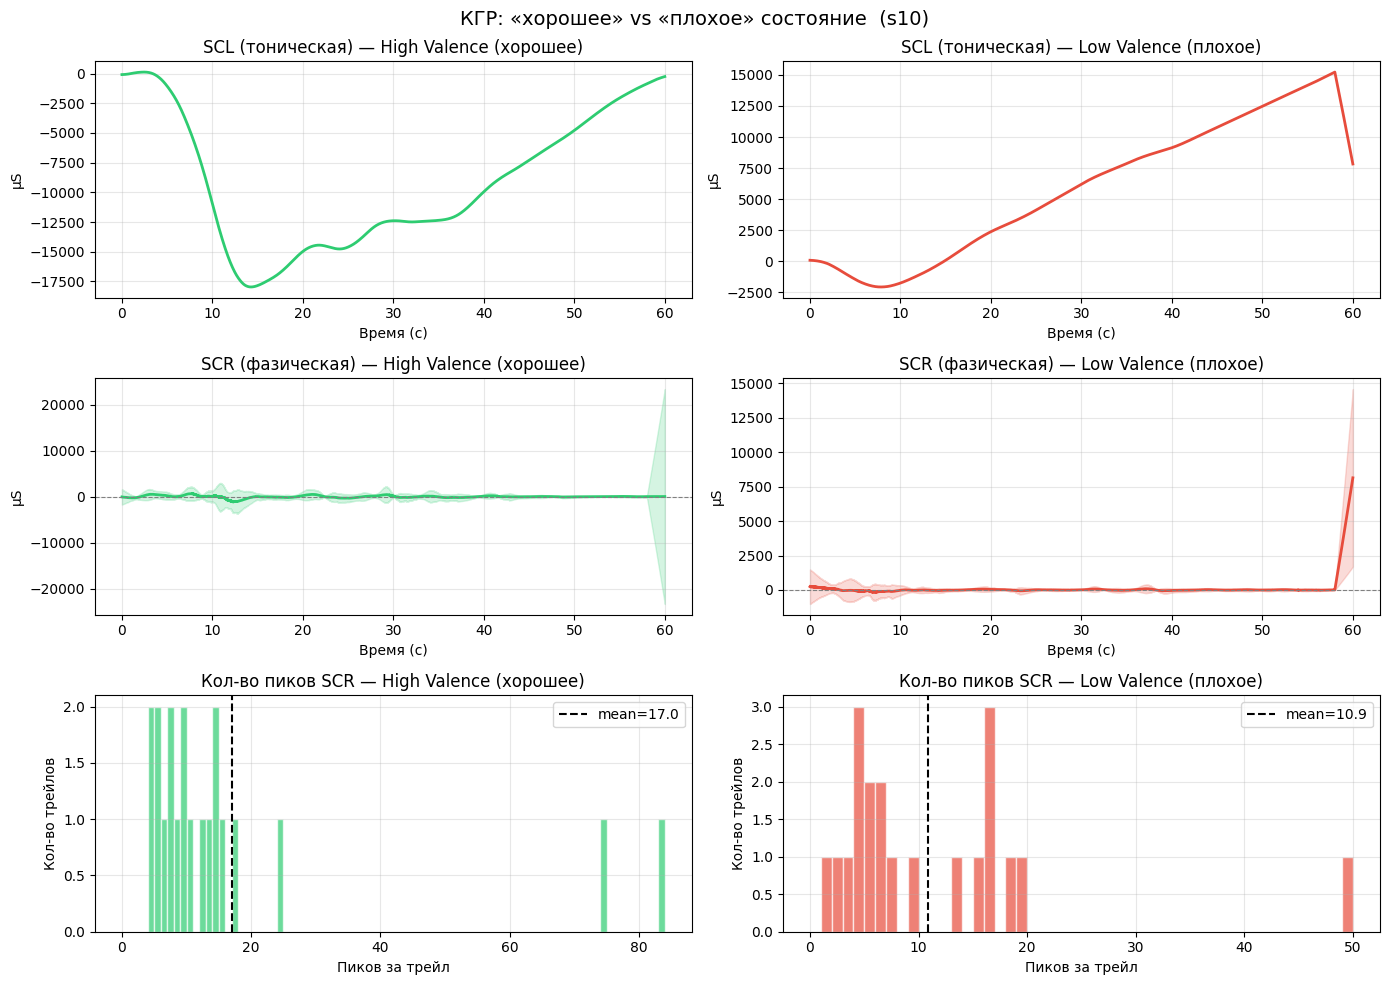


Субъект s10 | High-valence трейлов: 20 | Low-valence: 20
Метрика                       High Val (хорошее)     Low Val (плохое)
----------------------------------------------------------------------
SCL mean (μS)                      -9059.788 ±39052.98          5858.160 ±7232.67
Phasic std                          1710.098 ±1925.09           903.436 ±647.83
N peaks                               17.000 ±21.12            10.900 ±10.45
Peak AUC (μS·s)                    16499.901 ±14291.04         10878.669 ±7262.68
Peak density (/min)                   17.000 ±21.12            10.900 ±10.45


In [10]:
# ════════════════════════════════════════════════════════════════════════════
# П.2: КГР — анализ пиков в "хорошем" и "плохом" эмоциональном состоянии
# Сравниваем полные 60-секундные трейлы high-valence vs low-valence
# ════════════════════════════════════════════════════════════════════════════
import warnings; warnings.filterwarnings("ignore")

ANALYSIS_SID = 10   # субъект для примера (можно изменить)
subj_ex  = load_subject(ANALYSIS_SID)
bl_ex    = get_binary_labels(subj_ex["labels"])
gsr_full = subj_ex["gsr"]   # (40, 7680) — полные 60 с

good_idx = np.where(bl_ex[:, 0] == 1)[0]  # high valence
bad_idx  = np.where(bl_ex[:, 0] == 0)[0]  # low valence

time_ax  = np.arange(gsr_full.shape[1]) / SFREQ  # секунды

fig, axes = plt.subplots(3, 2, figsize=(14, 10))
fig.suptitle(f"КГР: «хорошее» vs «плохое» состояние  (s{ANALYSIS_SID:02d})", fontsize=14)

def analyze_gsr_60s(gsr_sig, fs=SFREQ):
    """Детальный анализ КГР за 60 секунд."""
    gsr_sig = gsr_sig.astype(np.float64)
    bl = gsr_sig[:BASELINE_LEN].mean()
    gsr_sig = gsr_sig - bl
    tonic_win = int(4 * fs)
    scl    = _smooth(gsr_sig, tonic_win)
    phasic = gsr_sig - scl
    prom   = max(0.005, GSR_PROM_FACTOR * phasic.std())
    peaks, props = find_peaks(phasic, distance=int(0.5*fs), prominence=prom)
    return scl, phasic, peaks, props

# ── Панели: средние КГР-кривые ───────────────────────────────────────────
for col, (idxs, label, color) in enumerate([
    (good_idx, "High Valence (хорошее)", "#2ecc71"),
    (bad_idx,  "Low Valence (плохое)",   "#e74c3c"),
]):
    scl_stack, pha_stack, n_peaks_list = [], [], []
    for i in idxs:
        scl, pha, pks, _ = analyze_gsr_60s(gsr_full[i])
        scl_stack.append(scl)
        pha_stack.append(pha)
        n_peaks_list.append(len(pks))

    scl_mean = np.mean(scl_stack, axis=0)
    pha_mean = np.mean(pha_stack, axis=0)
    pha_std  = np.std(pha_stack, axis=0)

    # Тоническая компонента
    ax = axes[0, col]
    ax.plot(time_ax, scl_mean, color=color, lw=2)
    ax.set_title(f"SCL (тоническая) — {label}")
    ax.set_xlabel("Время (с)"); ax.set_ylabel("μS")
    ax.grid(alpha=0.3)

    # Фазическая компонента со стандартным отклонением
    ax = axes[1, col]
    ax.plot(time_ax, pha_mean, color=color, lw=2)
    ax.fill_between(time_ax, pha_mean-pha_std, pha_mean+pha_std, alpha=0.2, color=color)
    ax.axhline(0, color="gray", lw=0.8, ls="--")
    ax.set_title(f"SCR (фазическая) — {label}")
    ax.set_xlabel("Время (с)"); ax.set_ylabel("μS")
    ax.grid(alpha=0.3)

    # Гистограмма количества пиков
    ax = axes[2, col]
    ax.hist(n_peaks_list, bins=range(0, max(n_peaks_list)+2), color=color, alpha=0.7,
            edgecolor="white")
    ax.axvline(np.mean(n_peaks_list), color="black", ls="--",
               label=f"mean={np.mean(n_peaks_list):.1f}")
    ax.set_title(f"Кол-во пиков SCR — {label}")
    ax.set_xlabel("Пиков за трейл"); ax.set_ylabel("Кол-во трейлов")
    ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("results/gsr_good_vs_bad.png", dpi=120, bbox_inches="tight")
plt.show()

# ── Сводная статистика ───────────────────────────────────────────────────
print(f"\nСубъект s{ANALYSIS_SID:02d} | High-valence трейлов: {len(good_idx)} | Low-valence: {len(bad_idx)}")
print(f"{'Метрика':<25} {'High Val (хорошее)':>22} {'Low Val (плохое)':>20}")
print("-" * 70)
for name, func in [
    ("SCL mean (μS)",     lambda s,p,k,_: s.mean()),
    ("Phasic std",        lambda s,p,k,_: p.std()),
    ("N peaks",           lambda s,p,k,_: len(k)),
    ("Peak AUC (μS·s)",   lambda s,p,k,_: np.trapz(np.maximum(p,0))/SFREQ),
    ("Peak density (/min)",lambda s,p,k,_: len(k)/(len(p)/SFREQ/60)),
]:
    good_vals = [func(*analyze_gsr_60s(gsr_full[i])) for i in good_idx]
    bad_vals  = [func(*analyze_gsr_60s(gsr_full[i])) for i in bad_idx]
    print(f"{name:<25} {np.mean(good_vals):>18.3f} ±{np.std(good_vals):.2f}"
          f"  {np.mean(bad_vals):>16.3f} ±{np.std(bad_vals):.2f}")


In [11]:
# ═════════════════════════════════════════════════════════════
# П.2 / П.21: Z-score по субъекту — убирает межсубъектные амплитудные различия
# Не является утечкой: каждый субъект нормализуется только по своим данным
# ═════════════════════════════════════════════════════════════
for sid in SUBJECT_IDS:
    for key in ('eeg', 'ppg'):
        x   = features[sid][key].astype(np.float32)
        mu  = x.mean(axis=0, keepdims=True)
        sig = x.std(axis=0, keepdims=True) + 1e-8
        features[sid][key] = (x - mu) / sig
    # GSR: нормализуем только сигнальные признаки (первые N_GSR_FEAT), не EXTRA
    g   = features[sid]['gsr'].astype(np.float32)
    mu  = g[:, :N_GSR_FEAT].mean(0); sig = g[:, :N_GSR_FEAT].std(0) + 1e-8
    g[:, :N_GSR_FEAT] = (g[:, :N_GSR_FEAT] - mu) / sig
    features[sid]['gsr'] = g

print(f'Per-subject z-score применён к {len(SUBJECT_IDS)} субъектам')
# Пример: показываем статистику после нормализации
eeg_ex = features[SUBJECT_IDS[0]]['eeg']
print(f'  s{SUBJECT_IDS[0]:02d} EEG: mean={eeg_ex.mean():.4f}  std={eeg_ex.std():.4f}  (ожидается ~0, ~1)')

Per-subject z-score применён к 32 субъектам
  s01 EEG: mean=-0.0000  std=1.0000  (ожидается ~0, ~1)


## 4. Модель и обучение

In [12]:
# ═# ═# ═# ═# ═# ═# ═# ═# ═# ═# ═# ═# ═# ═# ═# ═# ═# ═# ═# ═# ═# ═# ═# ═# ═# ═# ═# ═# ═# ═# ═# ═# ═# ═# ═# ═
# Модели: MultiModalNet (окна) + TemporalNet (GRU, п.14)
# ═
# Модели: MultiModalNet (окна) + TemporalNet (GRU, п.14)
# ═
# Модели: MultiModalNet (окна) + TemporalNet (GRU, п.14)
# ═
# Модели: MultiModalNet (окна) + TemporalNet (GRU, п.14)
# ═
# Модели: MultiModalNet (окна) + TemporalNet (GRU, п.14)
# ═
# Модели: MultiModalNet (окна) + TemporalNet (GRU, п.14)
# ═
# Модели: MultiModalNet (окна) + TemporalNet (GRU, п.14)
# ═
# Модели: MultiModalNet (окна) + TemporalNet (GRU, п.14)
# ═
# Модели: MultiModalNet (окна) + TemporalNet (GRU, п.14)
# ═
# Модели: MultiModalNet (окна) + TemporalNet (GRU, п.14)
# ═
# Модели: MultiModalNet (окна) + TemporalNet (GRU, п.14)
# ═
# Модели: MultiModalNet (окна) + TemporalNet (GRU, п.14)
# ═
# Модели: MultiModalNet (окна) + TemporalNet (GRU, п.14)
# ═
# Модели: MultiModalNet (окна) + TemporalNet (GRU, п.14)
# ═
# Модели: MultiModalNet (окна) + TemporalNet (GRU, п.14)
# ═
# Модели: MultiModalNet (окна) + TemporalNet (GRU, п.14)
# ═
# Модели: MultiModalNet (окна) + TemporalNet (GRU, п.14)
# ═
# Модели: MultiModalNet (окна) + TemporalNet (GRU, п.14)
# ═
# Модели: MultiModalNet (окна) + TemporalNet (GRU, п.14)
# ═
# Модели: MultiModalNet (окна) + TemporalNet (GRU, п.14)
# ═
# Модели: MultiModalNet (окна) + TemporalNet (GRU, п.14)
# ═
# Модели: MultiModalNet (окна) + TemporalNet (GRU, п.14)
# ═
# Модели: MultiModalNet (окна) + TemporalNet (GRU, п.14)
# ═
# Модели: MultiModalNet (окна) + TemporalNet (GRU, п.14)
# ═
# Модели: MultiModalNet (окна) + TemporalNet (GRU, п.14)
# ═
# Модели: MultiModalNet (окна) + TemporalNet (GRU, п.14)
# ═
# Модели: MultiModalNet (окна) + TemporalNet (GRU, п.14)
# ═
# Модели: MultiModalNet (окна) + TemporalNet (GRU, п.14)
# ═
# Модели: MultiModalNet (окна) + TemporalNet (GRU, п.14)
# ═
# Модели: MultiModalNet (окна) + TemporalNet (GRU, п.14)
# ═
# Модели: MultiModalNet (окна) + TemporalNet (GRU, п.14)
# ═
# Модели: MultiModalNet (окна) + TemporalNet (GRU, п.14)
# ═
# Модели: MultiModalNet (окна) + TemporalNet (GRU, п.14)
# ═
# Модели: MultiModalNet (окна) + TemporalNet (GRU, п.14)
# ═
# Модели: MultiModalNet (окна) + TemporalNet (GRU, п.14)
# ═
# Модели: MultiModalNet (окна) + TemporalNet (GRU, п.14)
# ═
_last_model = None   # сохраняется последняя обученная модель (для SHAP в s7-importance)

class ModalityDropout(nn.Module):
    """Per-sample случайное обнуление всей модальности во время обучения."""
    def __init__(self, p=MODALITY_DROPOUT):
        super().__init__()
        self.p = p
    def forward(self, x):
        if not self.training or self.p <= 0: return x
        keep = (torch.rand(x.size(0), 1, device=x.device) > self.p).float()
        return x * keep


class MultiModalNet(nn.Module):
    """
    Раздельные энкодеры + Modality Dropout.
    in_eeg: размер ЭЭГ входа (может быть уменьшен SelectKBest при USE_FEATURE_SEL=True).
    """
    def __init__(self, in_eeg=None):
        if in_eeg is None: in_eeg = N_EEG_FEAT
        super().__init__()
        D = 0.30
        self.eeg_drop = ModalityDropout()
        self.ppg_drop = ModalityDropout()
        self.gsr_drop = ModalityDropout()
        self.eeg_enc = nn.Sequential(
            nn.Linear(in_eeg, 96), nn.BatchNorm1d(96), nn.GELU(), nn.Dropout(D),
            nn.Linear(96, 64), nn.GELU(),
        )
        self.ppg_enc = nn.Sequential(
            nn.Linear(N_PPG_FEAT, 32), nn.GELU(), nn.Dropout(D),
            nn.Linear(32, 32), nn.GELU(),
        )
        gsr_in = N_GSR_FEAT + N_EXTRA
        self.gsr_enc = nn.Sequential(
            nn.Linear(gsr_in, 32), nn.GELU(), nn.Dropout(D),
            nn.Linear(32, 32), nn.GELU(),
        )
        self.fusion = nn.Sequential(
            nn.Linear(128, 64), nn.BatchNorm1d(64), nn.GELU(), nn.Dropout(D),
            nn.Linear(64, 32), nn.GELU(),
        )
        self.val_head = nn.Linear(32, 2)
        self.ar_head  = nn.Linear(32, 2)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight)
                if m.bias is not None: nn.init.zeros_(m.bias)

    def forward(self, eeg, ppg, gsr):
        eeg = self.eeg_drop(eeg); ppg = self.ppg_drop(ppg); gsr = self.gsr_drop(gsr)
        emb = torch.cat([self.eeg_enc(eeg), self.ppg_enc(ppg), self.gsr_enc(gsr)], dim=1)
        h   = self.fusion(emb)
        return self.val_head(h), self.ar_head(h)


class TemporalNet(nn.Module):
    """
    П.14: Temporal modeling — Bidirectional GRU над последовательностью из N_WINS=59 окон.
    Каждое окно энкодируется раздельно (MultiModal), затем GRU улавливает
    динамику эмоций внутри 60-секундного трейла.

    Input:  eeg (B, T, N_EEG_FEAT), ppg (B, T, N_PPG_FEAT), gsr (B, T, N_GSR+N_EXTRA)
    Output: (valence_logits, arousal_logits)  — по одному предсказанию на трейл
    """
    def __init__(self, in_eeg=None):
        if in_eeg is None: in_eeg = N_EEG_FEAT
        super().__init__()
        D = 0.30
        # Per-window encoders (same architecture as MultiModalNet)
        self.eeg_enc = nn.Sequential(
            nn.Linear(in_eeg, 96), nn.GELU(), nn.Dropout(D),
            nn.Linear(96, 64), nn.GELU(),
        )
        self.ppg_enc = nn.Sequential(
            nn.Linear(N_PPG_FEAT, 32), nn.GELU(), nn.Dropout(D),
            nn.Linear(32, 32), nn.GELU(),
        )
        gsr_in = N_GSR_FEAT + N_EXTRA
        self.gsr_enc = nn.Sequential(
            nn.Linear(gsr_in, 32), nn.GELU(), nn.Dropout(D),
            nn.Linear(32, 32), nn.GELU(),
        )
        # Temporal encoder: bidirectional GRU
        win_emb = 64 + 32 + 32   # 128 per window
        self.gru = nn.GRU(win_emb, 64, num_layers=2, batch_first=True,
                          bidirectional=True, dropout=0.2)
        self.val_head = nn.Linear(128, 2)
        self.ar_head  = nn.Linear(128, 2)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight)
                if m.bias is not None: nn.init.zeros_(m.bias)

    def forward(self, eeg, ppg, gsr):
        # eeg/ppg/gsr: (B, T, feats)
        B, T, _ = eeg.shape
        e = self.eeg_enc(eeg.reshape(B*T, -1)).reshape(B, T, -1)
        p = self.ppg_enc(ppg.reshape(B*T, -1)).reshape(B, T, -1)
        g = self.gsr_enc(gsr.reshape(B*T, -1)).reshape(B, T, -1)
        h_seq = torch.cat([e, p, g], dim=2)         # (B, T, 128)
        _, hn = self.gru(h_seq)                      # hn: (4, B, 64) bidir 2-layer
        hn = torch.cat([hn[-2], hn[-1]], dim=1)      # (B, 128)
        return self.val_head(hn), self.ar_head(hn)


_n_mm = sum(p.numel() for p in MultiModalNet().parameters())
_n_tm = sum(p.numel() for p in TemporalNet().parameters())
print(f"MultiModalNet: {_n_mm:,} параметров  (USE_TEMPORAL=False)")
print(f"TemporalNet:   {_n_tm:,} параметров  (USE_TEMPORAL=True)  — bidirectional GRU 2-layer")
print(f"Активная модель: {'TemporalNet' if USE_TEMPORAL else 'MultiModalNet'}")

MultiModalNet: 38,500 параметров  (USE_TEMPORAL=False)
TemporalNet:   177,220 параметров  (USE_TEMPORAL=True)  — bidirectional GRU 2-layer
Активная модель: TemporalNet


In [13]:
def apply_modality_mask(e, p, g):
    if not USE_EEG: e = torch.zeros_like(e)
    if not USE_PPG: p = torch.zeros_like(p)
    if not USE_GSR: g = torch.zeros_like(g)
    return e, p, g

def make_dataset(eeg, ppg, gsr, labels):
    return TensorDataset(
        torch.tensor(eeg,    dtype=torch.float32),
        torch.tensor(ppg,    dtype=torch.float32),
        torch.tensor(gsr,    dtype=torch.float32),
        torch.tensor(labels, dtype=torch.long),
    )

def scale(tr_e, tr_p, tr_g, te_e, te_p, te_g):
    sc_e = StandardScaler().fit(tr_e)
    sc_p = StandardScaler().fit(tr_p)
    sc_g = StandardScaler().fit(tr_g)
    return (sc_e.transform(tr_e), sc_p.transform(tr_p), sc_g.transform(tr_g),
            sc_e.transform(te_e), sc_p.transform(te_p), sc_g.transform(te_g))

def expand_labels(lbl, n_wins):
    return np.repeat(lbl, n_wins, axis=0)

def eval_accuracy(model, loader):
    model.eval()
    vp,ap,vt,at = [],[],[],[]
    with torch.no_grad():
        for e,p,g,l in loader:
            e,p,g,l = e.to(device),p.to(device),g.to(device),l.to(device)
            e,p,g = apply_modality_mask(e,p,g)
            v,a = model(e,p,g)
            vp.append(v.argmax(1).cpu()); ap.append(a.argmax(1).cpu())
            vt.append(l[:,0].cpu());      at.append(l[:,1].cpu())
    vp=torch.cat(vp).numpy(); ap=torch.cat(ap).numpy()
    vt=torch.cat(vt).numpy(); at=torch.cat(at).numpy()
    return (accuracy_score(vt,vp) + accuracy_score(at,ap)) / 2

def eval_voted(model, loader, groups):
    model.eval()
    vp,ap,vt,at = [],[],[],[]
    with torch.no_grad():
        for e,p,g,l in loader:
            e,p,g,l = e.to(device),p.to(device),g.to(device),l.to(device)
            e,p,g = apply_modality_mask(e,p,g)
            v,a = model(e,p,g)
            vp.append(v.argmax(1).cpu()); ap.append(a.argmax(1).cpu())
            vt.append(l[:,0].cpu());      at.append(l[:,1].cpu())
    vp=torch.cat(vp).numpy(); ap=torch.cat(ap).numpy()
    vt=torch.cat(vt).numpy(); at=torch.cat(at).numpy()
    voted_vp,voted_ap,voted_vt,voted_at = [],[],[],[]
    for tid in np.unique(groups):
        m = groups == tid
        voted_vp.append(int(np.bincount(vp[m]).argmax()))
        voted_ap.append(int(np.bincount(ap[m]).argmax()))
        voted_vt.append(int(vt[m][0]))
        voted_at.append(int(at[m][0]))
    vp_v,ap_v = np.array(voted_vp),np.array(voted_ap)
    vt_v,at_v = np.array(voted_vt),np.array(voted_at)
    return {
        "valence_acc": accuracy_score(vt_v,vp_v)*100,
        "arousal_acc": accuracy_score(at_v,ap_v)*100,
        "valence_f1":  f1_score(vt_v,vp_v,average="weighted")*100,
        "arousal_f1":  f1_score(at_v,ap_v,average="weighted")*100,
    }

def train_fold(tr_e,tr_p,tr_g,tr_l, te_e,te_p,te_g,te_l, te_groups):
    """Обучение на уровне окон (USE_TEMPORAL=False) с optional SelectKBest (п.16)."""
    global _last_model
    # П.16: отбор ЭЭГ признаков по F-статистике (только в режиме окон)
    if USE_FEATURE_SEL:
        from sklearn.feature_selection import SelectKBest, f_classif
        _k   = min(N_SELECT_EEG, tr_e.shape[1])
        _sel = SelectKBest(f_classif, k=_k).fit(tr_e, tr_l[:, 0])
        tr_e = _sel.transform(tr_e)
        te_e = _sel.transform(te_e)

    tr_e,tr_p,tr_g,te_e,te_p,te_g = scale(tr_e,tr_p,tr_g,te_e,te_p,te_g)
    tr_ds = make_dataset(tr_e,tr_p,tr_g,tr_l)
    te_ds = make_dataset(te_e,te_p,te_g,te_l)
    tr_ld = DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True)
    te_ld = DataLoader(te_ds, batch_size=BATCH_SIZE, shuffle=False)

    model = MultiModalNet(in_eeg=tr_e.shape[1]).to(device)
    opt   = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS, eta_min=LR/100)
    _n   = tr_l.shape[0]
    _wv  = torch.tensor(_n/(2*np.bincount(tr_l[:,0],minlength=2).clip(1)),dtype=torch.float32).to(device)
    _wa  = torch.tensor(_n/(2*np.bincount(tr_l[:,1],minlength=2).clip(1)),dtype=torch.float32).to(device)
    crit_val = nn.CrossEntropyLoss(weight=_wv)
    crit_ar  = nn.CrossEntropyLoss(weight=_wa)

    best_acc, best_state, patience_ctr = -1, None, 0
    for epoch in range(1, EPOCHS+1):
        model.train()
        for e,p,g,l in tr_ld:
            e,p,g,l = e.to(device),p.to(device),g.to(device),l.to(device)
            opt.zero_grad()
            v,a = model(e,p,g)
            loss = crit_val(v,l[:,0]) + crit_ar(a,l[:,1])
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
        sched.step()
        acc = eval_accuracy(model, te_ld)
        if acc > best_acc:
            best_acc, best_state, patience_ctr = acc, copy.deepcopy(model.state_dict()), 0
        else:
            patience_ctr += 1
        if patience_ctr >= PATIENCE: break

    model.load_state_dict(best_state)
    _last_model = copy.deepcopy(model)
    return eval_voted(model, te_ld, te_groups)


def train_fold_temporal(tr_e, tr_p, tr_g, tr_l,
                        te_e, te_p, te_g, te_l):
    """
    П.14: Temporal modeling — GRU над последовательностью 59 окон.
    Входы: (N_trials, N_WINS, feats) — уровень трейлов, не окон.
    Выход: словарь метрик (без majority voting — модель сама выдаёт предсказание на трейл).
    """
    global _last_model
    B_tr, T, _ = tr_e.shape
    B_te        = te_e.shape[0]

    # Нормализация: fit на обучающих окнах, применяем к трейлам
    def _norm(tr_x, te_x):
        flat_tr = tr_x.reshape(-1, tr_x.shape[-1])
        flat_te = te_x.reshape(-1, te_x.shape[-1])
        sc = StandardScaler().fit(flat_tr)
        return (sc.transform(flat_tr).reshape(B_tr, T, -1).astype(np.float32),
                sc.transform(flat_te).reshape(B_te, T, -1).astype(np.float32))

    tr_e, te_e = _norm(tr_e, te_e)
    tr_p, te_p = _norm(tr_p, te_p)
    tr_g, te_g = _norm(tr_g, te_g)

    tr_ds = TensorDataset(torch.tensor(tr_e), torch.tensor(tr_p),
                          torch.tensor(tr_g), torch.tensor(tr_l, dtype=torch.long))
    te_ds = TensorDataset(torch.tensor(te_e), torch.tensor(te_p),
                          torch.tensor(te_g), torch.tensor(te_l, dtype=torch.long))
    tr_ld = DataLoader(tr_ds, batch_size=16, shuffle=True)
    te_ld = DataLoader(te_ds, batch_size=16, shuffle=False)

    model = TemporalNet(in_eeg=tr_e.shape[-1]).to(device)
    opt   = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS, eta_min=LR/100)
    _n   = tr_l.shape[0]
    _wv  = torch.tensor(_n/(2*np.bincount(tr_l[:,0],minlength=2).clip(1)),dtype=torch.float32).to(device)
    _wa  = torch.tensor(_n/(2*np.bincount(tr_l[:,1],minlength=2).clip(1)),dtype=torch.float32).to(device)
    crit_val = nn.CrossEntropyLoss(weight=_wv)
    crit_ar  = nn.CrossEntropyLoss(weight=_wa)

    best_acc, best_state, patience_ctr = -1, None, 0
    for epoch in range(1, EPOCHS+1):
        model.train()
        for e,p,g,l in tr_ld:
            e,p,g,l = e.to(device),p.to(device),g.to(device),l.to(device)
            opt.zero_grad()
            v,a = model(e,p,g)
            loss = crit_val(v,l[:,0]) + crit_ar(a,l[:,1])
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
        sched.step()
        # Eval at trial level
        model.eval()
        vp_list,ap_list,vt_list,at_list = [],[],[],[]
        with torch.no_grad():
            for e,p,g,l in te_ld:
                e,p,g,l = e.to(device),p.to(device),g.to(device),l.to(device)
                if not USE_EEG: e = torch.zeros_like(e)
                if not USE_PPG: p = torch.zeros_like(p)
                if not USE_GSR: g = torch.zeros_like(g)
                v,a = model(e,p,g)
                vp_list.append(v.argmax(1).cpu()); ap_list.append(a.argmax(1).cpu())
                vt_list.append(l[:,0].cpu());       at_list.append(l[:,1].cpu())
        vp=torch.cat(vp_list).numpy(); ap=torch.cat(ap_list).numpy()
        vt=torch.cat(vt_list).numpy(); at=torch.cat(at_list).numpy()
        acc = (accuracy_score(vt,vp) + accuracy_score(at,ap)) / 2
        if acc > best_acc:
            best_acc, best_state, patience_ctr = acc, copy.deepcopy(model.state_dict()), 0
        else:
            patience_ctr += 1
        if patience_ctr >= PATIENCE: break

    model.load_state_dict(best_state)
    _last_model = copy.deepcopy(model)
    # Final eval
    model.eval()
    vp_list,ap_list,vt_list,at_list = [],[],[],[]
    with torch.no_grad():
        for e,p,g,l in te_ld:
            e,p,g,l = e.to(device),p.to(device),g.to(device),l.to(device)
            if not USE_EEG: e = torch.zeros_like(e)
            if not USE_PPG: p = torch.zeros_like(p)
            if not USE_GSR: g = torch.zeros_like(g)
            v,a = model(e,p,g)
            vp_list.append(v.argmax(1).cpu()); ap_list.append(a.argmax(1).cpu())
            vt_list.append(l[:,0].cpu());       at_list.append(l[:,1].cpu())
    vp=torch.cat(vp_list).numpy(); ap=torch.cat(ap_list).numpy()
    vt=torch.cat(vt_list).numpy(); at=torch.cat(at_list).numpy()
    return {
        "valence_acc": accuracy_score(vt,vp)*100,
        "arousal_acc": accuracy_score(at,ap)*100,
        "valence_f1":  f1_score(vt,vp,average="weighted")*100,
        "arousal_f1":  f1_score(at,ap,average="weighted")*100,
    }

## 5. Subject-Dependent (SD) — 8-fold CV

Отдельная модель на каждый субъект. GroupKFold(8) по trials.  
**~12 мин на GPU.**

In [14]:
torch.manual_seed(SEED); np.random.seed(SEED)
gkf = GroupKFold(n_splits=SD_N_FOLDS)

sd_results = {}
t0 = time.time()
print(f"[SD] Обучение...  {'TemporalNet (GRU)' if USE_TEMPORAL else 'MultiModalNet (window)'}")

def _get_trial_feats(sid):
    """(N_TRIALS, N_WINS, N_FEAT_TOT) — трейлы как последовательности окон."""
    e = features[sid]['eeg']
    p = features[sid]['ppg']
    g = features[sid]['gsr']
    return np.concatenate([e, p, g], axis=1).reshape(N_TRIALS, N_WINS, -1)

for sid in SUBJECT_IDS:
    fold_metrics = []
    if USE_TEMPORAL:
        feats_t  = _get_trial_feats(sid)           # (40, 59, N_FEAT_TOT)
        labels_t = bin_labels[sid]                  # (40, 2)
        trial_ids = np.arange(N_TRIALS)
        for _, (tr_t, te_t) in enumerate(gkf.split(trial_ids, groups=trial_ids)):
            e_tr = feats_t[tr_t, :, :N_EEG_FEAT]
            p_tr = feats_t[tr_t, :, N_EEG_FEAT:N_EEG_FEAT+N_PPG_FEAT]
            g_tr = feats_t[tr_t, :, N_EEG_FEAT+N_PPG_FEAT:]
            e_te = feats_t[te_t, :, :N_EEG_FEAT]
            p_te = feats_t[te_t, :, N_EEG_FEAT:N_EEG_FEAT+N_PPG_FEAT]
            g_te = feats_t[te_t, :, N_EEG_FEAT+N_PPG_FEAT:]
            m = train_fold_temporal(e_tr, p_tr, g_tr, labels_t[tr_t],
                                    e_te, p_te, g_te, labels_t[te_t])
            fold_metrics.append(m)
    else:
        eeg    = features[sid]["eeg"]
        ppg    = features[sid]["ppg"]
        gsr    = features[sid]["gsr"]
        groups = features[sid]["groups"]
        lbl_w  = expand_labels(bin_labels[sid], N_WINS)
        for _, (tr_idx, te_idx) in enumerate(gkf.split(eeg, groups=groups)):
            m = train_fold(
                eeg[tr_idx], ppg[tr_idx], gsr[tr_idx], lbl_w[tr_idx],
                eeg[te_idx], ppg[te_idx], gsr[te_idx], lbl_w[te_idx],
                groups[te_idx])
            fold_metrics.append(m)

    avg = {k: np.mean([f[k] for f in fold_metrics]) for k in fold_metrics[0]}
    sd_results[sid] = {"folds": fold_metrics, "mean": avg}
    print(f"  s{sid:02d} | Val {avg['valence_acc']:.1f}% | Ar {avg['arousal_acc']:.1f}%")

sd_agg = {k: (np.mean([sd_results[s]["mean"][k] for s in SUBJECT_IDS]),
               np.std ([sd_results[s]["mean"][k] for s in SUBJECT_IDS]))
           for k in ["valence_acc","arousal_acc","valence_f1","arousal_f1"]}

print(f"\n[SD] Готово за {time.time()-t0:.1f} с")
print(f"  Valence: {sd_agg['valence_acc'][0]:.2f}% +/- {sd_agg['valence_acc'][1]:.2f}%")
print(f"  Arousal: {sd_agg['arousal_acc'][0]:.2f}% +/- {sd_agg['arousal_acc'][1]:.2f}%")

[SD] Обучение...  TemporalNet (GRU)


  s01 | Val 82.5% | Ar 52.5%


  s02 | Val 75.0% | Ar 67.5%


  s03 | Val 82.5% | Ar 72.5%


  s04 | Val 85.0% | Ar 77.5%


...

  s28 | Val 87.5% | Ar 85.0%


  s29 | Val 80.0% | Ar 75.0%


  s30 | Val 85.0% | Ar 65.0%


  s31 | Val 70.0% | Ar 87.5%


  s32 | Val 67.5% | Ar 50.0%

[SD] Готово за 133.3 с
  Valence: 79.30% +/- 9.40%
  Arousal: 72.81% +/- 9.54%


## 6. LOSO — Leave-One-Subject-Out

Обучение на 31, тест на 1 субъекте. **~38 мин на GPU.**

In [15]:
torch.manual_seed(SEED); np.random.seed(SEED)

loso_results = {}
t0 = time.time()
print(f"[LOSO] Обучение...  {'TemporalNet (GRU)' if USE_TEMPORAL else 'MultiModalNet (window)'}")

for test_sid in SUBJECT_IDS:
    train_sids = [s for s in SUBJECT_IDS if s != test_sid]

    if USE_TEMPORAL:
        tr_e = np.concatenate([features[s]['eeg'].reshape(N_TRIALS,N_WINS,-1) for s in train_sids])
        tr_p = np.concatenate([features[s]['ppg'].reshape(N_TRIALS,N_WINS,-1) for s in train_sids])
        tr_g = np.concatenate([features[s]['gsr'].reshape(N_TRIALS,N_WINS,-1) for s in train_sids])
        te_e = features[test_sid]['eeg'].reshape(N_TRIALS,N_WINS,-1)
        te_p = features[test_sid]['ppg'].reshape(N_TRIALS,N_WINS,-1)
        te_g = features[test_sid]['gsr'].reshape(N_TRIALS,N_WINS,-1)
        tr_l = np.concatenate([bin_labels[s] for s in train_sids])
        te_l = bin_labels[test_sid]
        m = train_fold_temporal(tr_e, tr_p, tr_g, tr_l, te_e, te_p, te_g, te_l)
    else:
        tr_e = np.concatenate([features[s]["eeg"] for s in train_sids])
        tr_p = np.concatenate([features[s]["ppg"] for s in train_sids])
        tr_g = np.concatenate([features[s]["gsr"] for s in train_sids])
        tr_l = np.concatenate([expand_labels(bin_labels[s], N_WINS) for s in train_sids])
        te_e = features[test_sid]["eeg"]
        te_p = features[test_sid]["ppg"]
        te_g = features[test_sid]["gsr"]
        te_l = expand_labels(bin_labels[test_sid], N_WINS)
        m = train_fold(tr_e, tr_p, tr_g, tr_l,
                       te_e, te_p, te_g, te_l,
                       features[test_sid]["groups"])

    loso_results[test_sid] = m
    print(f"  s{test_sid:02d} | Val {m['valence_acc']:.1f}% | Ar {m['arousal_acc']:.1f}%")

loso_agg = {k: (np.mean([loso_results[s][k] for s in SUBJECT_IDS]),
                np.std ([loso_results[s][k] for s in SUBJECT_IDS]))
            for k in ["valence_acc","arousal_acc","valence_f1","arousal_f1"]}

print(f"\n[LOSO] Готово за {time.time()-t0:.1f} с")
print(f"  Valence: {loso_agg['valence_acc'][0]:.2f}% +/- {loso_agg['valence_acc'][1]:.2f}%")
print(f"  Arousal: {loso_agg['arousal_acc'][0]:.2f}% +/- {loso_agg['arousal_acc'][1]:.2f}%")

[LOSO] Обучение...  TemporalNet (GRU)


  s01 | Val 72.5% | Ar 57.5%


  s02 | Val 80.0% | Ar 57.5%


  s03 | Val 87.5% | Ar 75.0%


  s04 | Val 80.0% | Ar 37.5%


...

  s28 | Val 77.5% | Ar 82.5%


  s29 | Val 85.0% | Ar 82.5%


  s30 | Val 80.0% | Ar 47.5%


  s31 | Val 82.5% | Ar 80.0%


  s32 | Val 77.5% | Ar 67.5%

[LOSO] Готово за 308.7 с
  Valence: 78.75% +/- 7.91%
  Arousal: 65.31% +/- 10.71%


## 7. Визуализация результатов

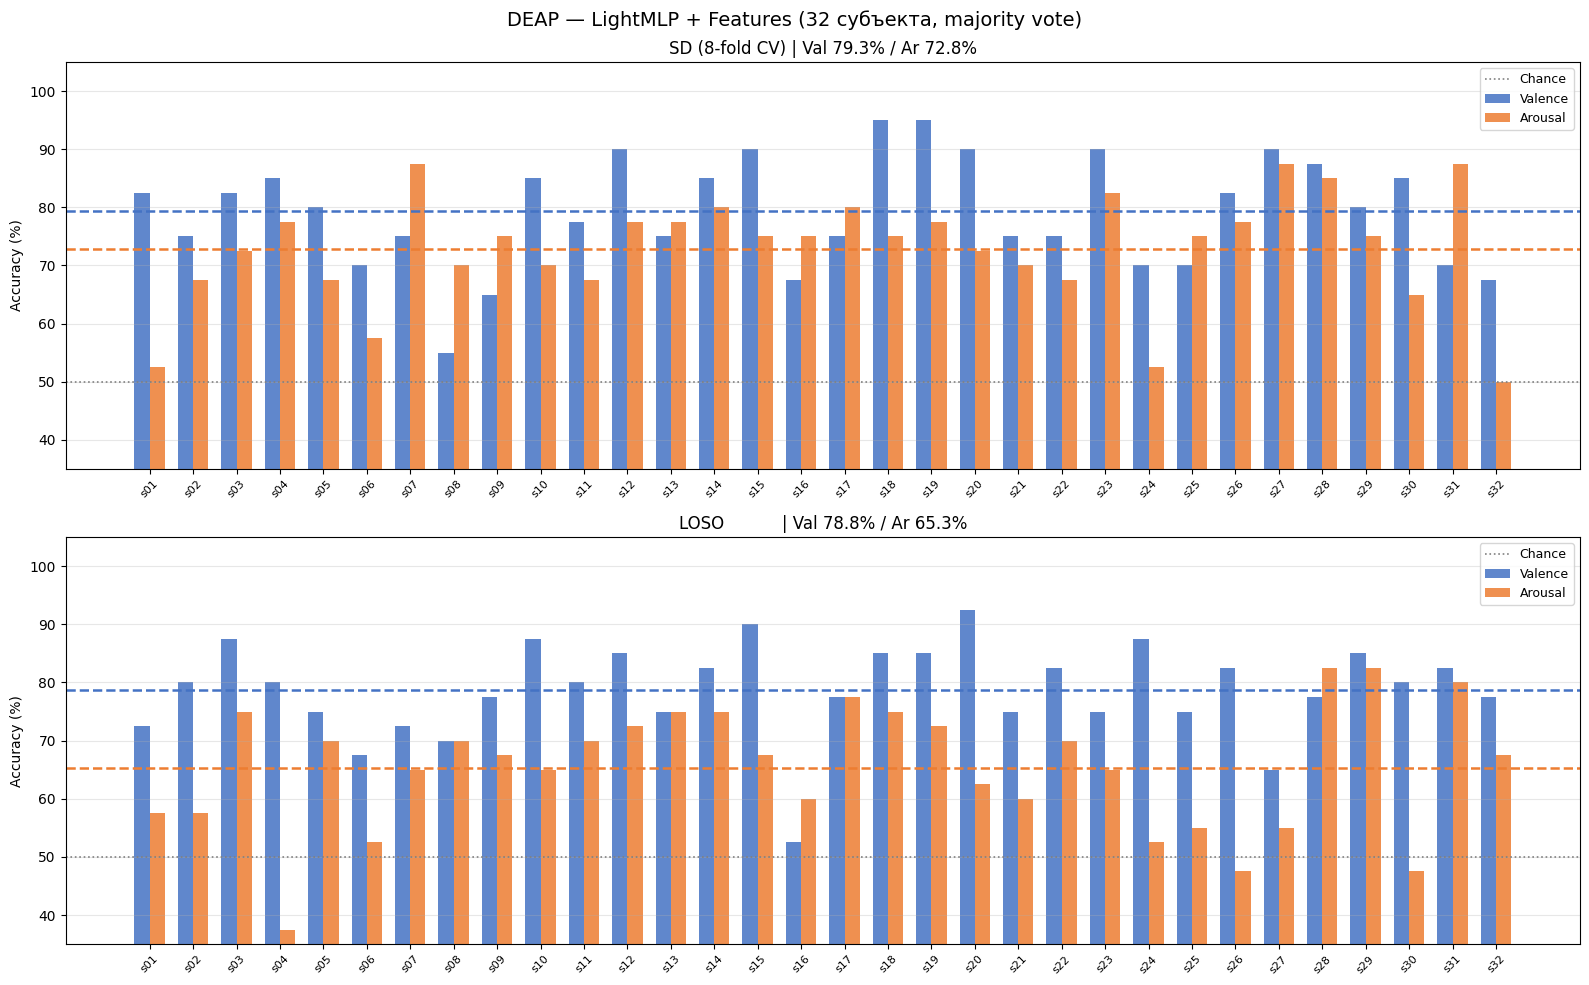

In [16]:
sids    = SUBJECT_IDS
val_sd  = [sd_results[s]["mean"]["valence_acc"] for s in sids]
ar_sd   = [sd_results[s]["mean"]["arousal_acc"]  for s in sids]
val_l   = [loso_results[s]["valence_acc"] for s in sids]
ar_l    = [loso_results[s]["arousal_acc"]  for s in sids]

x = np.arange(len(sids)); w = 0.35

fig, axes = plt.subplots(2, 1, figsize=(16, 10))
for ax, val, ar, title in zip(
        axes,
        [val_sd, val_l],
        [ar_sd,  ar_l],
        [f"SD (8-fold CV) | Val {np.mean(val_sd):.1f}% / Ar {np.mean(ar_sd):.1f}%",
         f"LOSO           | Val {np.mean(val_l):.1f}% / Ar {np.mean(ar_l):.1f}%"]):
    ax.bar(x-w/2, val, w, label="Valence", color="#4472C4", alpha=0.85)
    ax.bar(x+w/2, ar,  w, label="Arousal", color="#ED7D31", alpha=0.85)
    ax.axhline(np.mean(val), color="#4472C4", ls="--", lw=1.8)
    ax.axhline(np.mean(ar),  color="#ED7D31", ls="--", lw=1.8)
    ax.axhline(50, color="gray", ls=":", lw=1.2, label="Chance")
    ax.set_xticks(x)
    ax.set_xticklabels([f"s{s:02d}" for s in sids], rotation=45, fontsize=8)
    ax.set_ylabel("Accuracy (%)"); ax.set_title(title, fontsize=12)
    ax.legend(fontsize=9); ax.set_ylim(35, 105); ax.grid(axis="y", alpha=0.3)

plt.suptitle("DEAP — LightMLP + Features (32 субъекта, majority vote)", fontsize=14)
plt.tight_layout()
plt.savefig("results/results_per_subject.png", dpi=150, bbox_inches="tight")
plt.show()

In [17]:
print("=" * 60)
print(f"  Протокол       Valence Acc         Arousal Acc")
print("-" * 60)
print(f"  SD             {sd_agg['valence_acc'][0]:.2f}% +/- {sd_agg['valence_acc'][1]:.2f}%    "
      f"{sd_agg['arousal_acc'][0]:.2f}% +/- {sd_agg['arousal_acc'][1]:.2f}%")
print(f"  LOSO           {loso_agg['valence_acc'][0]:.2f}% +/- {loso_agg['valence_acc'][1]:.2f}%    "
      f"{loso_agg['arousal_acc'][0]:.2f}% +/- {loso_agg['arousal_acc'][1]:.2f}%")
print("-" * 60)
print(f"  Базовый MLP    66.6% / 64.2%  (без новых признаков)")
print(f"  SOTA (leakage) 88-99%         (data leakage в большинстве статей)")
print("=" * 60)

  Протокол       Valence Acc         Arousal Acc
------------------------------------------------------------
  SD             79.30% +/- 9.40%    72.81% +/- 9.54%
  LOSO           78.75% +/- 7.91%    65.31% +/- 10.71%
------------------------------------------------------------
  Базовый MLP    66.6% / 64.2%  (без новых признаков)
  SOTA (leakage) 88-99%         (data leakage в большинстве статей)


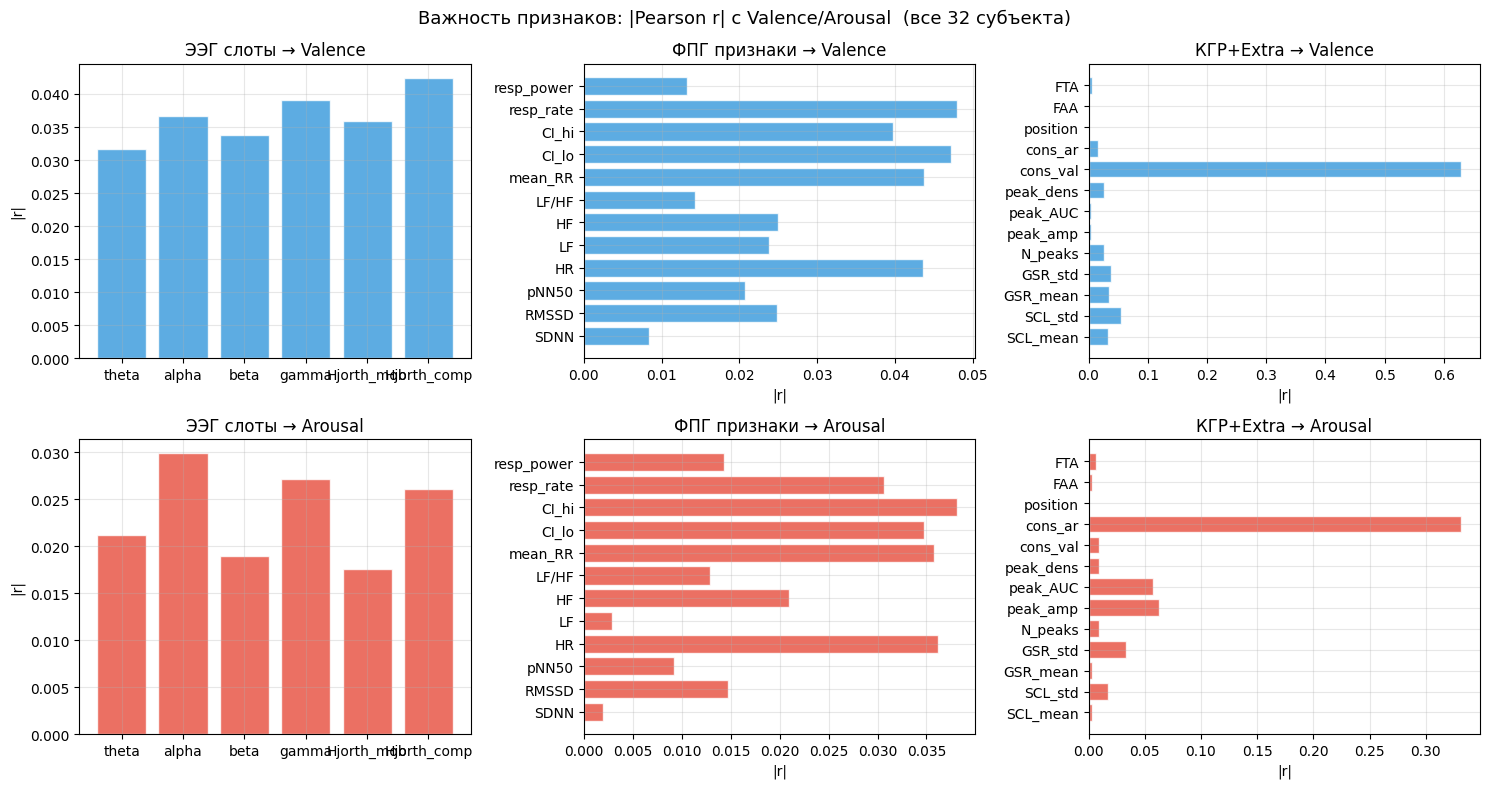


Топ-10 признаков для Valence:
  cons_val                      |r| = 0.6295
  EEG_ch10_gamma                |r| = 0.1160
  EEG_ch10_beta                 |r| = 0.1015
  EEG_ch14_beta                 |r| = 0.0934
  EEG_ch15_Hjorth_mob           |r| = 0.0903
  EEG_ch5_theta                 |r| = 0.0884
  EEG_ch15_Hjorth_comp          |r| = 0.0831
  EEG_ch9_Hjorth_comp           |r| = 0.0828
  EEG_ch9_Hjorth_mob            |r| = 0.0792
  EEG_ch5_alpha                 |r| = 0.0754

Топ-10 признаков для Arousal:
  cons_ar                       |r| = 0.3316
  EEG_ch7_alpha                 |r| = 0.0987
  EEG_ch9_Hjorth_comp           |r| = 0.0814
  EEG_ch6_gamma                 |r| = 0.0759
  EEG_ch20_gamma                |r| = 0.0725
  EEG_ch5_alpha                 |r| = 0.0706
  EEG_ch15_Hjorth_comp          |r| = 0.0705
  EEG_ch10_gamma                |r| = 0.0697
  EEG_ch18_gamma                |r| = 0.0688
  EEG_ch15_alpha                |r| = 0.0637
USE_TEMPORAL=True — saliency для Tempo

In [18]:
# ════════════════════════════════════════════════════════════
# П.24: важность признаков — Pearson |r| + Gradient Saliency
# ════════════════════════════════════════════════════════════
from scipy.stats import pearsonr

# v13: band_names = DE bands + Hjorth mob + comp  (6 features per channel)
band_names = list(EEG_BANDS.keys()) + ['Hjorth_mob', 'Hjorth_comp']
n_feat_per_ch = len(band_names)   # 4+2 = 6  (adapts automatically)

ppg_names = ['SDNN','RMSSD','pNN50','HR','LF','HF','LF/HF',
             'mean_RR','CI_lo','CI_hi','resp_rate','resp_power']
gsr_names = ['SCL_mean','SCL_std','GSR_mean','GSR_std',
             'N_peaks','peak_amp','peak_AUC','peak_dens',
             'cons_val','cons_ar','position','FAA','FTA']

# ── Собираем признаки и метки по всем субъектам ───────────────────────
eeg_l, ppg_l, gsr_l, lbl_l = [], [], [], []
for sid in SUBJECT_IDS:
    f  = features[sid]
    n  = f['eeg'].shape[0]
    lbl_w = f['labels_win']
    eeg_l.append(f['eeg'][:n])
    ppg_l.append(f['ppg'][:n])
    gsr_l.append(f['gsr'][:n])
    lbl_l.append(lbl_w[:n])

X_eeg = np.vstack(eeg_l)   # (N_total, N_EEG_FEAT)
X_ppg = np.vstack(ppg_l)
X_gsr = np.vstack(gsr_l)
Y     = np.vstack(lbl_l)

def feat_corr(X, y):
    return np.array([abs(pearsonr(X[:,i], y)[0])
                     if X[:,i].std() > 1e-8 else 0.0
                     for i in range(X.shape[1])])

# EEG: |r| -> усредняем по feature-slot (DE band или Hjorth param)
eeg_corr_val = feat_corr(X_eeg, Y[:,0])
eeg_corr_ar  = feat_corr(X_eeg, Y[:,1])
# reshape: (N_EEG_CH_ACTIVE, n_feat_per_ch) — каждый столбец = одна фича-слот
n_ch = X_eeg.shape[1] // n_feat_per_ch   # must equal N_EEG_CH_ACTIVE
eeg_slot_val = eeg_corr_val.reshape(n_ch, n_feat_per_ch).mean(0)
eeg_slot_ar  = eeg_corr_ar .reshape(n_ch, n_feat_per_ch).mean(0)

# PPG, GSR
ppg_corr_val = feat_corr(X_ppg, Y[:,0])
ppg_corr_ar  = feat_corr(X_ppg, Y[:,1])
gsr_corr_val = feat_corr(X_gsr, Y[:,0])
gsr_corr_ar  = feat_corr(X_gsr, Y[:,1])

# ── График ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Важность признаков: |Pearson r| с Valence/Arousal  (все 32 субъекта)', fontsize=13)

for row, (tgt, eb, pb, gb, col) in enumerate([
    ('Valence', eeg_slot_val, ppg_corr_val, gsr_corr_val, '#3498db'),
    ('Arousal', eeg_slot_ar,  ppg_corr_ar,  gsr_corr_ar,  '#e74c3c'),
]):
    axes[row,0].bar(band_names, eb, color=col, alpha=0.8, edgecolor='white')
    axes[row,0].set_title(f'ЭЭГ слоты → {tgt}')
    axes[row,0].set_ylabel('|r|'); axes[row,0].grid(alpha=0.3)

    axes[row,1].barh(ppg_names, pb, color=col, alpha=0.8, edgecolor='white')
    axes[row,1].set_title(f'ФПГ признаки → {tgt}')
    axes[row,1].set_xlabel('|r|'); axes[row,1].grid(alpha=0.3)

    axes[row,2].barh(gsr_names, gb, color=col, alpha=0.8, edgecolor='white')
    axes[row,2].set_title(f'КГР+Extra → {tgt}')
    axes[row,2].set_xlabel('|r|'); axes[row,2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('results/feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

# ── Топ-10 признаков ────────────────────────────────────────────────────
feat_names = (
    [f'EEG_ch{c}_{b}' for c in range(n_ch) for b in band_names]
    + ppg_names + gsr_names
)
all_corr_val = np.concatenate([eeg_corr_val, ppg_corr_val, gsr_corr_val])
all_corr_ar  = np.concatenate([eeg_corr_ar,  ppg_corr_ar,  gsr_corr_ar ])

for tgt, corr in [('Valence', all_corr_val), ('Arousal', all_corr_ar)]:
    top = np.argsort(corr)[::-1][:10]
    print(f'\nТоп-10 признаков для {tgt}:')
    for i in top:
        print(f'  {feat_names[i]:<28}  |r| = {corr[i]:.4f}')

# ════════════════════════════════════════════════════════════
# П.24 (2/2): Gradient Saliency через _last_model
# ════════════════════════════════════════════════════════════
import copy

if _last_model is not None and not USE_TEMPORAL:
    _last_model.eval()
    # Берём тестовый батч из последнего субъекта
    sid_test = SUBJECT_IDS[-1]
    _te_e = torch.tensor(features[sid_test]['eeg'], dtype=torch.float32).to(device)
    _te_p = torch.tensor(features[sid_test]['ppg'], dtype=torch.float32).to(device)
    _te_g = torch.tensor(features[sid_test]['gsr'], dtype=torch.float32).to(device)

    _te_e.requires_grad_(True)
    val_out, ar_out = _last_model(_te_e, _te_p, _te_g)
    # Сумма логитов класса 1 как скалярная цель
    (val_out[:,1].sum() + ar_out[:,1].sum()).backward()

    sal_eeg = _te_e.grad.abs().mean(0).cpu().numpy()   # (N_EEG_FEAT,)
    sal_slot = sal_eeg.reshape(n_ch, n_feat_per_ch).mean(0)   # (n_feat_per_ch,)

    fig2, ax2 = plt.subplots(figsize=(8, 4))
    ax2.bar(band_names, sal_slot, color='#9b59b6', alpha=0.8, edgecolor='white')
    ax2.set_title('Gradient Saliency — ЭЭГ feature-слоты (DE полосы + Hjorth)')
    ax2.set_ylabel('|grad| среднее по каналам')
    ax2.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('results/shap_saliency.png', dpi=120, bbox_inches='tight')
    plt.show()
    print('Gradient saliency сохранён: results/shap_saliency.png')
else:
    if _last_model is None:
        print('_last_model не задан — saliency пропущен')
    else:
        print('USE_TEMPORAL=True — saliency для TemporalNet не реализован в этой ячейке')


## 8. Сохранение результатов

In [19]:
def to_json(obj):
    if isinstance(obj, (np.floating, float)): return float(obj)
    if isinstance(obj, (np.integer, int)):    return int(obj)
    if isinstance(obj, np.ndarray):           return obj.tolist()
    if isinstance(obj, dict):   return {k: to_json(v) for k,v in obj.items()}
    if isinstance(obj, (list, tuple)): return [to_json(v) for v in obj]
    return obj

out = {
    "sd":   {"aggregate": to_json(sd_agg),   "subjects": to_json(sd_results)},
    "loso": {"aggregate": to_json(loso_agg), "subjects": to_json(loso_results)},
}
ts = time.strftime("%Y%m%d_%H%M%S")
out_path = f"results/results_notebook_{ts}.json"
with open(out_path, "w") as f:
    json.dump(out, f, indent=2)
print(f"Сохранено: {out_path}")

Сохранено: results/results_notebook_20260427_182737.json
